In [1]:
from libMilne import *
import os
from concurrent.futures import ProcessPoolExecutor
fmToGeV = 1/0.197327

/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1112: SyntaxWarning: invalid escape sequence '\s'
  """
/home/andrea/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
"""
    In this cell we get the entire grids for the integrands of energy density, pressure, spin density and spin torque using the exact diagonalization
    of the canonical pseudogauge with a fixed spin potential. We expect that for a small spin potential the values will be comparable with those
    obtained in the Belinfante pseudogauge.
    
    Evaluating this cell should take around 4-5 mins. Reduce N to accelerate.
"""


# Parameters
mass = 1.0
tau = 1.0
Temp = 1.0
beta = 1.0/Temp
SP = 1e-5
mu_T = 0.0

# Integration limits
mu_min, mu_max = -10.0, 10.0
px_min, px_max = -10.0, 10.0
py_min, py_max = -10.0, 10.0

# Number of points per dimension
N = 20+1  

# Create grid. This function creates a grid which is denser around the middle point of the interval (in this case, the origin)
mu_grid = middle_dense_grid(N, mu_min, mu_max)
px_grid = middle_dense_grid(N, px_min, px_max)
py_grid = middle_dense_grid(N, py_min, py_max)

# Initialize 3D array
integrand_gridE = np.zeros((N, N, N))
integrand_gridPT = np.zeros((N, N, N))
integrand_gridPL = np.zeros((N, N, N))
integrand_gridS = np.zeros((N, N, N))
integrand_gridT = np.zeros((N, N, N))

# Loop over grid points
for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            resE,resPT,resPL, resS, resT = tabulating_canonical(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=80
            )
            integrand_gridE[i,j,k] = float(to_numpy(resE))
            integrand_gridPT[i,j,k] = float(to_numpy(resPT))
            integrand_gridPL[i,j,k] = float(to_numpy(resPL))
            integrand_gridS[i,j,k] = float(to_numpy(resS))
            integrand_gridT[i,j,k] = float(to_numpy(resT))

# Integration            
_ = simpson(integrand_gridE, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
E_can = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridPT, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
PT_can = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridPL, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
PL_can = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridT, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
Torque = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridS, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
SpinDens = simpson(_, x=py_grid, axis=0)

print(f"Integral E result SP = {SP}: ", E_can)
print(f"Integral PT result SP = {SP}: ", PT_can)
print(f"Integral PL result SP = {SP}: ", PL_can)
print(f"Integral S result SP = {SP}: ", SpinDens)
print(f"Integral T result SP = {SP}: ", Torque)


/tmp/ipykernel_13468/400967262.py:45: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridE[i,j,k] = float(to_numpy(resE))
/tmp/ipykernel_13468/400967262.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridPT[i,j,k] = float(to_numpy(resPT))
/tmp/ipykernel_13468/400967262.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridPL[i,j,k] = float(to_numpy(resPL))
/tmp/ipykernel_13468/400967262.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridS[i,j,k] = float(to_numpy(resS))
/tmp/ipykernel_13468/400967262.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridT[i,j,k] = float(to_numpy(resT))


Integral E result SP = 1e-05:  1.0588715400986461
Integral PT result SP = 1e-05:  0.3162892152651265
Integral PL result SP = 1e-05:  0.31629170714909677
Integral S result SP = 1e-05:  -1.570731589075354e-05
Integral T result SP = 1e-05:  -0.00044987789929662057


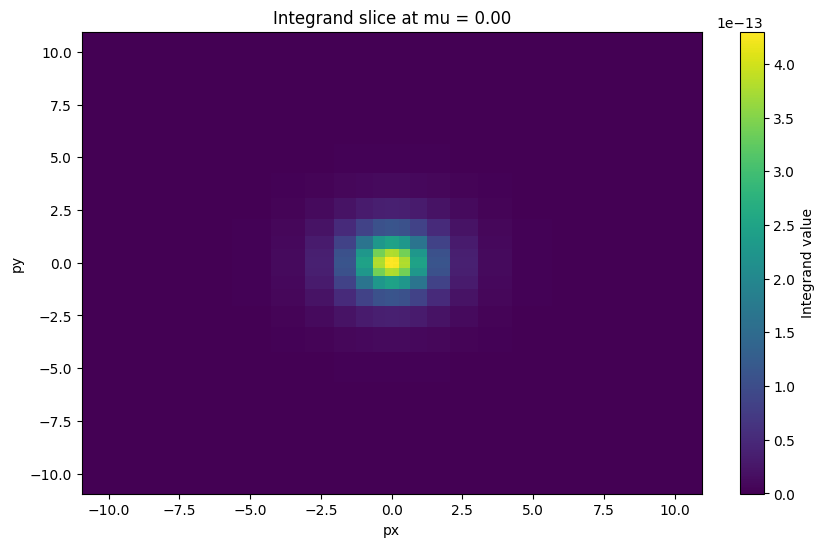

In [11]:
"""
    You can check the integrands by plotting slices like in this cell
"""

plot_integrand_slice(integrand_gridPL, mu_grid, px_grid, py_grid, x_axis=1,y_axis=2)

In [18]:
"""
    We can compare the previous results with those obtained with the same method and grid with the analytic formulae at SP=0 in the belinfante pseudogauge.
    We can also evaluate the results from the partition function.
    
    This cell evaluates in seconds.
"""

integrand_gridBELE = np.zeros((N, N, N))
integrand_gridBELPT = np.zeros((N, N, N))
integrand_gridBELPL = np.zeros((N, N, N))
integrandLogZ_P = np.zeros((N, N, N))
integrandLogZ_S = np.zeros((N, N, N))


for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            resE,resPT,resPL = tabulating_belinfante(
                mass, px, py, mu, tau, beta, precision=50
            )
            integrand_gridBELE[i, j, k],integrand_gridBELPT[i, j, k],integrand_gridBELPL[i, j, k] = float(to_numpy(resE)),float(to_numpy(resPT)),float(to_numpy(resPL))
            integrandLogZ_P[i,j,k], integrandLogZ_S[i,j,k], _ = tabulating_logZ(mass, px, py, mu, tau, beta, SP, precision = 50)
            
_ = simpson(integrand_gridBELE, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
E_bel = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridBELPT, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
PT_bel = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridBELPL, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
PL_bel = simpson(_, x=py_grid, axis=0)

_ = simpson(integrandLogZ_P, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
ZPres = simpson(_, x=py_grid, axis=0)

_ = simpson(integrandLogZ_S, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
Zentr = simpson(_, x=py_grid, axis=0)

print("Integral E result belinfante: ", E_bel)
print("Integral PT result belinfante: ", PT_bel)
print("Integral PL result belinfante: ", PL_bel)
print("Integral E from logZ: ", -ZPres+Temp*Zentr)
print("Integral P from logZ: ", ZPres)

/tmp/ipykernel_13468/438103241.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridBELE[i, j, k],integrand_gridBELPT[i, j, k],integrand_gridBELPL[i, j, k] = float(to_numpy(resE)),float(to_numpy(resPT)),float(to_numpy(resPL))


Integral E result belinfante:  1.058869711601892
Integral PT result belinfante:  0.31629170710932
Integral PL result belinfante:  0.3162917071093199
Integral E from logZ:  1.0588797385831967
Integral P from logZ:  0.31727957658859807


## Evaluate in parallel for different values of Spin potential

In [ ]:
"""
    Here we perform a parallel evaluation of the integrals using nproc processors for a list of Spin potentials. Each value of SP will be handeled
    by a different processor. Make sure the output_dir exists before executing this cell. 
    
    This is evalueted by default on a small grid. Increase N to gain precision. If you test other values of mass, tau and Temp, make sure that the
    cuts in the domain are adequate and the precision used to evaluate Hankel functions is sufficient.
    
    In the current form, this cell should run in ~ 3 mins. Increase N to improve precision.
"""
nproc = 6

output_dir="./test"
# Parameters
mass = 1.0
tau = 1.0
Temp = 1.0
beta = 1.0 / Temp
Omlist = np.linspace(1e-5,3,24) ## This is a list in Omega, SP=Om*beta
mu_T = 0.0


# Integration limits and grid
mu_min, mu_max = -10, 10.0
px_min, px_max = -10.0, 10.0
py_min, py_max = -10.0, 10.0
N = 10+1

mu_grid = middle_dense_grid(N, mu_min, mu_max)
px_grid = middle_dense_grid(N, px_min, px_max)
py_grid = middle_dense_grid(N, py_min, py_max)


with ProcessPoolExecutor(max_workers=nproc) as executor:
    futures = [executor.submit(
        process_Om_tofile,
        Om, mass, tau, beta, mu_T, mu_grid, px_grid, py_grid, output_dir=output_dir
    ) for Om in Omlist]  # this function creates a file for each value of Om, containing, Om, E, PT, PL, Spin_dens, Torque 

    for future in futures:
        res = future.result()
        print(f"Saved results for Om = {res[0]}")
        
joinSPfiles(output_dir,mass,beta,tau,mu_T) #This function joins all the files in the output dir, for a more comfortable plotting

/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridE[i,j,k] = float(to_numpy(resE))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridPT[i,j,k] = float(to_numpy(resPT))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridPL[i,j,k] = float(to_numpy(resPL))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1366: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridS[i,j,k] = float(to_numpy(resS))
/home/andrea/Desktop/Università/Work/Art

/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridPT[i,j,k] = float(to_numpy(resPT))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridPL[i,j,k] = float(to_numpy(resPL))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1366: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridS[i,j,k] = float(to_numpy(resS))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1367: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridT[i,j,k] = float(to_numpy(resT))
/home/andrea/Desktop/Università/Work/Art

Saved results for Om = 1e-05
Saved results for Om = 0.13044434782608696
Saved results for Om = 0.2608786956521739
Saved results for Om = 0.39131304347826085
Saved results for Om = 0.5217473913043478
Saved results for Om = 0.6521817391304348
Saved results for Om = 0.7826160869565216
Saved results for Om = 0.9130504347826086
Saved results for Om = 1.0434847826086957
Saved results for Om = 1.1739191304347827
Saved results for Om = 1.3043534782608697
Saved results for Om = 1.4347878260869567
Saved results for Om = 1.5652221739130434
Saved results for Om = 1.6956565217391304
Saved results for Om = 1.8260908695652174
Saved results for Om = 1.9565252173913044
Saved results for Om = 2.0869595652173913
Saved results for Om = 2.217393913043478
Saved results for Om = 2.3478282608695653
Saved results for Om = 2.478262608695652
Saved results for Om = 2.6086969565217393
Saved results for Om = 2.739131304347826
Saved results for Om = 2.8695656521739132
Saved results for Om = 3.0


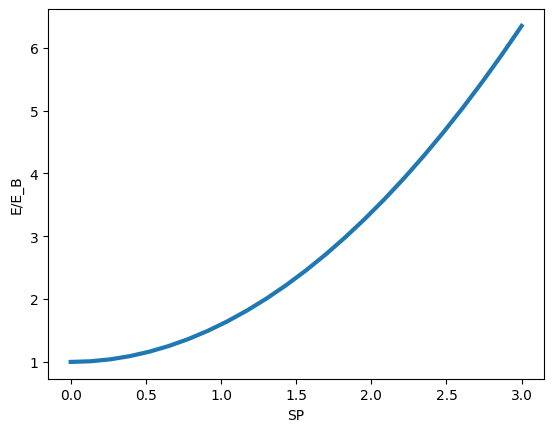

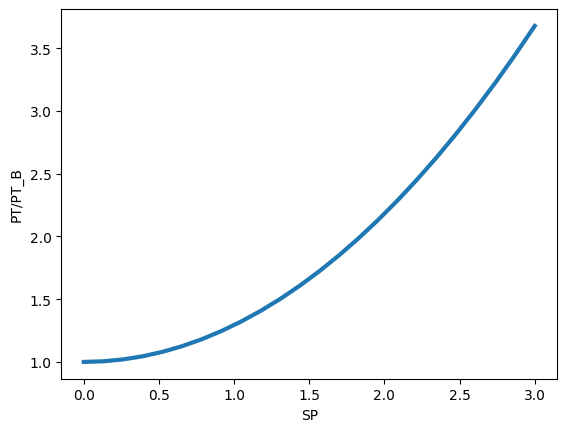

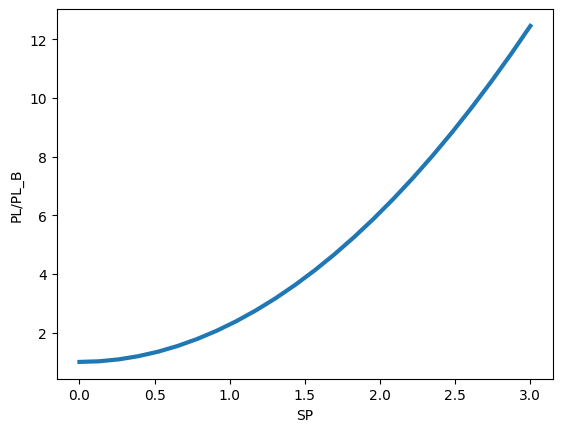

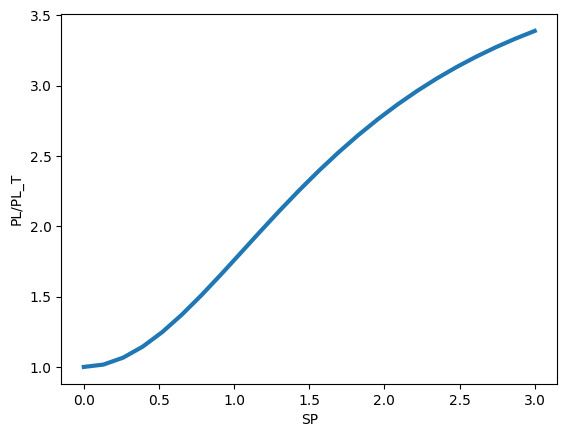

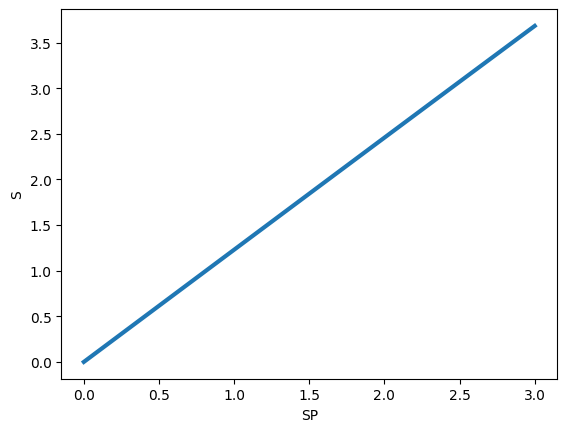

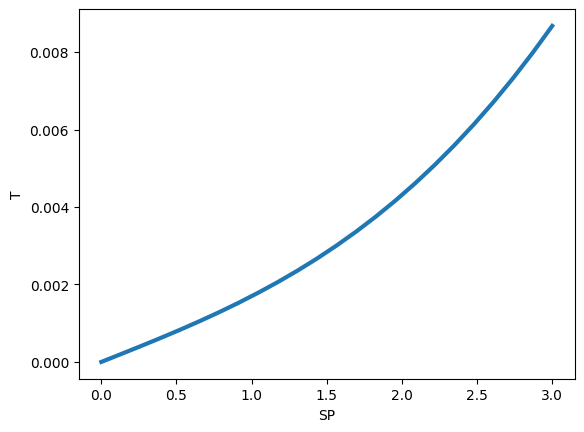

In [9]:
"""
    Now you can read the results of the resulting file and plot them
"""

theOmlist, Elist, PTlist, PLlist,Slist,Tlist = np.loadtxt(f"./{output_dir}/joined_mass={mass}_Temp={Temp}_tau={tau}_mu_T={mu_T}.txt")

plt.figure()
plt.plot(theOmlist, Elist/Elist[0], linewidth=3)
plt.xlabel("SP")
plt.ylabel("E/E_B")

# Plot 2
plt.figure()
plt.plot(theOmlist, PTlist/PTlist[0], linewidth=3)
plt.xlabel("SP")
plt.ylabel("PT/PT_B")

plt.figure()
plt.plot(theOmlist, PLlist/PLlist[0], linewidth=3)
plt.xlabel("SP")
plt.ylabel("PL/PL_B")

plt.figure()
plt.plot(theOmlist, PLlist/PTlist, linewidth=3)
plt.xlabel("SP")
plt.ylabel("PL/PL_T")

plt.figure()
plt.plot(theOmlist, Slist, linewidth=3)
plt.xlabel("SP")
plt.ylabel("S")

plt.figure()
plt.plot(theOmlist, Tlist, linewidth=3)
plt.xlabel("SP")
plt.ylabel("T")

plt.show()

/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1326: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridP[i,j,k] = float(to_numpy(resP))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1326: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridP[i,j,k] = float(to_numpy(resP))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1326: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridP[i,j,k] = float(to_numpy(resP))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1326: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridP[i,j,k] = float(to_numpy(resP))
/home/andrea/Desktop/Università/Work/Articol

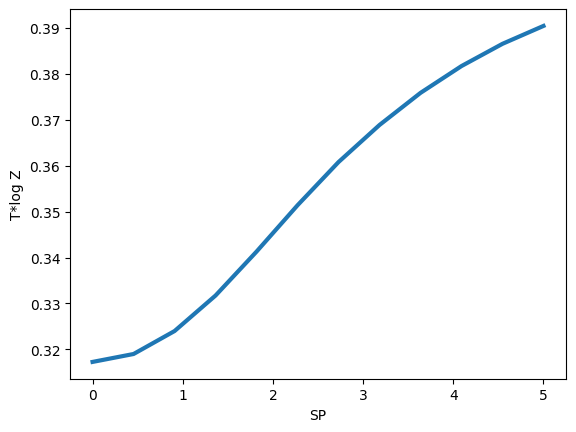

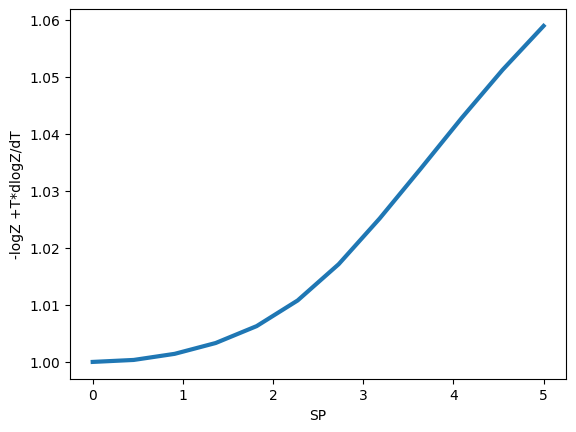

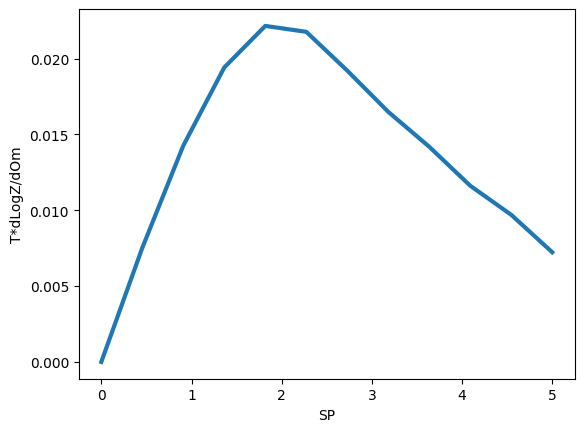

In [30]:
"""
    You can also check the results of logZ. 
    
    This cell runs in ~ seconds
"""

# Parameters
mass = 1
tau = 1.0
Temp = 1.0
beta = 1.0/Temp
SPlist = np.linspace(1e-5,5,12)
mu_T = 0.0

# Integration limits
mu_min, mu_max = -10, 10.0
px_min, px_max = -10.0, 10.0
py_min, py_max = -10.0, 10.0

# Number of points per dimension
N = 20+1  # Adjust for speed/resolution

# Create grid
mu_grid = middle_dense_grid(N, mu_min, mu_max)
px_grid = middle_dense_grid(N, px_min, px_max)
py_grid = middle_dense_grid(N, py_min, py_max)

Elist = np.array([])
PTlist = np.array([])
PLlist = np.array([])
Slist = np.array([])
Tlist = np.array([])

with ProcessPoolExecutor(max_workers=nproc) as executor:
    results = list(executor.map(
        process_logZ,
        SPlist,
        [mass]*len(SPlist),
        [tau]*len(SPlist),
        [beta]*len(SPlist),
        [mu_grid]*len(SPlist),
        [px_grid]*len(SPlist),
        [py_grid]*len(SPlist),
    ))


Plist, P_dTlist, Slist = zip(*results)

# Update your lists
Plist = np.array(Plist)
P_dTlist = np.array(P_dTlist)
Entrlist = np.array(Slist)



plt.figure()
plt.plot(SPlist, Plist, linewidth=3)
plt.xlabel("SP")
plt.ylabel("T*log Z")

plt.figure()
plt.plot(SPlist, (-Plist+Temp*P_dTlist)/(-Plist[0]+Temp*P_dTlist[0]), linewidth=3)
plt.xlabel("SP")
plt.ylabel("-logZ +T*dlogZ/dT")

plt.figure()
plt.plot(SPlist, Slist, linewidth=3)
plt.xlabel("SP")
plt.ylabel("T*dLogZ/dOm")

plt.show()

## Polarization

In [5]:
"""
    Now we can evaluate polarization. In this case we do it for a realistic Lambda particle, so we need a much larger mu interval and a larger precision.
    
    Luckily, we only need to integrate in mu, so it's not that bad. This cell runs in ~1 min
"""

# Parameters
mass = 1.167
tau = 10.0*fmToGeV
Temp = 0.15
beta = 1.0/Temp
Omegalist = np.linspace(1e-5,3,12)
SPlist = 1/Temp*Omegalist
mu_T = 0.0
px = 0.1
py = 0

# Integration limits
mu_min, mu_max = -60, 60.0

# Number of points per dimension
N = 100  # Adjust for speed/resolution
# prec = 300

with ProcessPoolExecutor(max_workers=6) as executor:
    polarization_list = list(executor.map(process_Polarization, SPlist,
                                            [mass]*len(SPlist),
                                            [px]*len(SPlist),
                                            [py]*len(SPlist),
                                            [tau]*len(SPlist),
                                            [beta]*len(SPlist),
                                            [mu_T]*len(SPlist),
                                            [mu_min]*len(SPlist),
                                            [mu_max]*len(SPlist),
                                            [N]*len(SPlist)
    ))  
   

/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1404: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridD[i] = float(to_numpy(resD))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1404: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridD[i] = float(to_numpy(resD))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridZ[i] = float(to_numpy(resZ))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1404: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridD[i] = float(to_numpy(resD))
/home/andrea/Desktop/Università/Work/Articoli/polarization M

In [3]:
"""
    For pT=0 we can also evaluate using the analytic formula...
"""

exactlist = []
for Om in Omegalist:
    exactlist.append(exact_polarization_longitudinal(mass, tau, beta, Om/Temp, precision = 50))      

<>:9: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_28558/2627111184.py:9: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel("$\Omega$ [Gev]")


Text(0, 0.5, '$P_z$ [Gev]')

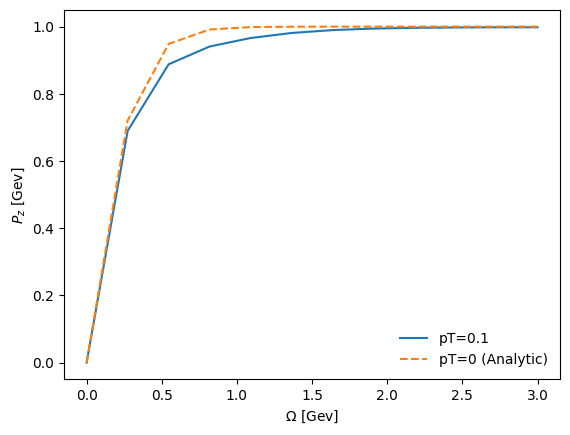

In [6]:
"""
    ... and we can can compare the results.
"""

plt.plot(Omegalist, polarization_list, label=f"pT={np.sqrt(px**2+py**2)}")
plt.plot(Omegalist, exactlist,linestyle="--", label=f"pT=0 (Analytic)")

plt.legend(frameon=False)
plt.xlabel("$\Omega$ [Gev]")
plt.ylabel("$P_z$ [Gev]")